In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv(r"datasets/raw/dataset 1/Training Dataset.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [39]:
print("Info:\n",df.info(),"\n")
print("Describe:\n",df.describe(),"\n")
print("Shape:\n",df.shape,"\n")
print("Columns:\n",df.columns,"\n")
print("Data Types:\n",df.dtypes,"\n")
print("Null Values:\n",df.isnull().sum(),"\n")
print("Duplicates:\n",df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
Info:
 None 

Describe:
                Age  Years of Experience         Salary
count  6702.000000          6701.000000    6699.000000
mean     33.620859             8.094687  115326.964771
std       7.614633             6.059003   52786.183911
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            

In [40]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower().str.replace(" ", "_")

df['job_title'] = df['job_title'].str.lower().str.strip()
df['education_level'] = df['education_level'].str.lower().str.strip()
df['gender'] = df['gender'].str.lower().str.strip()

In [41]:
df = df.dropna()
df = df.drop_duplicates()
df['age'] = df['age'].astype(int)
df['years_of_experience'] = df['years_of_experience'].astype(int)
df['salary'] = df['salary'].astype(int)

In [42]:
df = df[df["salary"] > 1200]

In [43]:
print("Head:\n",df.head(),"\n")
print("Info:\n",df.info(),"\n")
print("Describe:\n",df.describe(),"\n")
print("Shape:\n",df.shape,"\n")
print("Columns:\n",df.columns,"\n")
print("Data Types:\n",df.dtypes,"\n")
print("Null Values:\n",df.isnull().sum(),"\n")
print("Duplicates:\n",df.duplicated().sum())

Head:
    age  gender education_level          job_title  years_of_experience  salary
0   32    male      bachelor's  software engineer                    5   90000
1   28  female        master's       data analyst                    3   65000
2   45    male             phd     senior manager                   15  150000
3   36  female      bachelor's    sales associate                    7   60000
4   52    male        master's           director                   20  200000 

<class 'pandas.core.frame.DataFrame'>
Index: 1783 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  1783 non-null   int64 
 1   gender               1783 non-null   object
 2   education_level      1783 non-null   object
 3   job_title            1783 non-null   object
 4   years_of_experience  1783 non-null   int64 
 5   salary               1783 non-null   int64 
dtypes: int64(3), object

In [44]:
df.head(10)

,age,gender,education_level,job_title,years_of_experience,salary
0,32,male,bachelor's,software engineer,5,90000
1,28,female,master's,data analyst,3,65000
2,45,male,phd,senior manager,15,150000
3,36,female,bachelor's,sales associate,7,60000
4,52,male,master's,director,20,200000
5,29,male,bachelor's,marketing analyst,2,55000
6,42,female,master's,product manager,12,120000
7,31,male,bachelor's,sales manager,4,80000
8,26,female,bachelor's,marketing coordinator,1,45000
9,38,male,phd,senior scientist,10,110000


In [45]:
df["education_level"] = df["education_level"].replace({
"bachelor's degree": "bachelor's",
"master's degree": "master's",
"phd": "phd"
})

df['job_title'] = df['job_title'].replace({
    'juniour hr generalist': 'junior hr generalist',
    'juniour hr coordinator': 'junior hr coordinator',
    'customer service rep': 'customer service representative',
    'hr manager': 'human resources manager',
    'director of hr': 'human resources director'
})

In [46]:
print("Unique job titles: ", df["job_title"].nunique())
print("Unique job titles: ", df["job_title"].unique())
print("Education levels: ", df["education_level"].nunique())
print("Education levels: ", df["education_level"].unique())
print("Gender categories: ", df["gender"].nunique())
print("Gender categories: ", df["gender"].unique())


Unique job titles:  185
Unique job titles:  ['software engineer' 'data analyst' 'senior manager' 'sales associate'
 'director' 'marketing analyst' 'product manager' 'sales manager'
 'marketing coordinator' 'senior scientist' 'software developer'
 'human resources manager' 'financial analyst' 'project manager'
 'customer service representative' 'operations manager'
 'marketing manager' 'senior engineer' 'data entry clerk' 'sales director'
 'business analyst' 'vp of operations' 'it support' 'recruiter'
 'financial manager' 'social media specialist' 'software manager'
 'junior developer' 'senior consultant' 'product designer' 'ceo'
 'accountant' 'data scientist' 'marketing specialist' 'technical writer'
 'hr generalist' 'project engineer' 'customer success rep'
 'sales executive' 'ux designer' 'operations director' 'network engineer'
 'administrative assistant' 'strategy consultant' 'copywriter'
 'account manager' 'director of marketing' 'help desk analyst'
 'customer service manager' 'bu

In [47]:
df.select_dtypes(include='number').corr()

,age,years_of_experience,salary
age,1.000000,0.936119,0.767069
years_of_experience,0.936119,1.000000,0.819188
salary,0.767069,0.819188,1.000000


In [48]:
df.groupby('education_level')['salary'].mean()

education_level
bachelor's      91501.169935
high school     45435.981818
master's       127432.806338
phd            161414.179412
Name: salary, dtype: float64

In [49]:
df.groupby('gender')['salary'].mean()

gender
female    107557.778325
male      118300.164938
other     125819.000000
Name: salary, dtype: float64

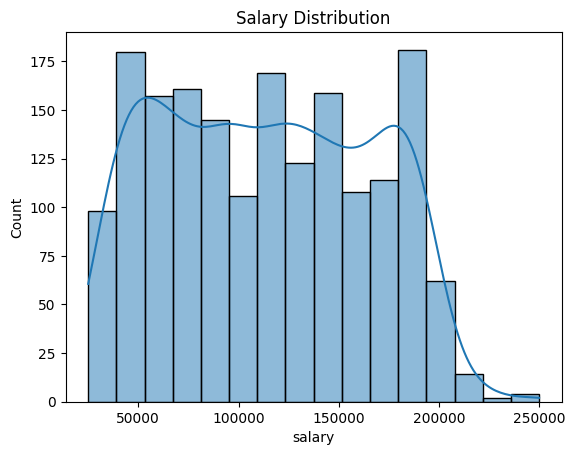

In [50]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

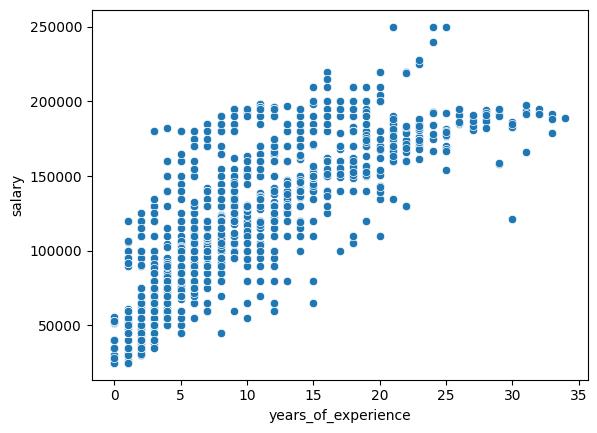

In [51]:
sns.scatterplot(x=df['years_of_experience'], y=df['salary'])
plt.show()

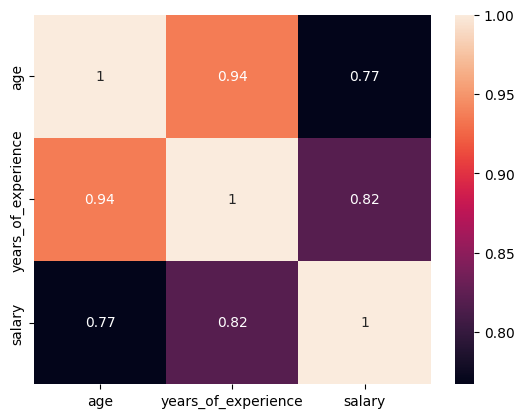

In [52]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

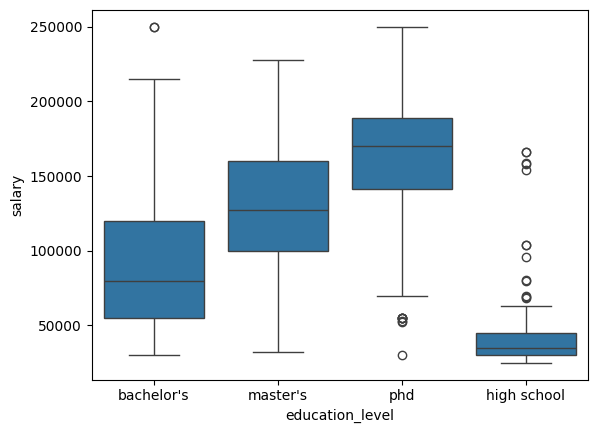

In [53]:
sns.boxplot(x=df['education_level'], y=df['salary'])
plt.show()

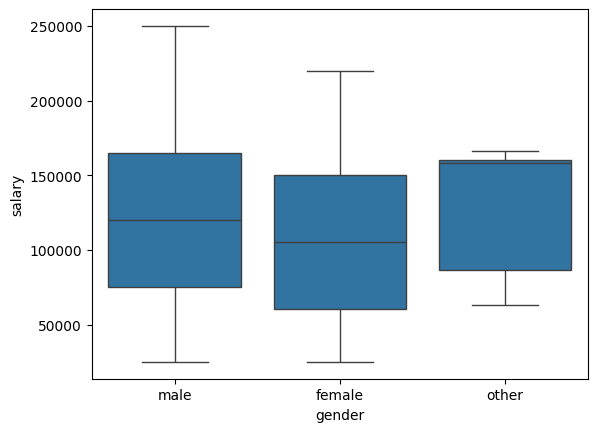

In [54]:
sns.boxplot(x=df['gender'], y=df['salary'])
plt.show()

## insights
1 Work experience is the most influential factor in determining salary.

2 Education level has a clear impact on income, with higher degrees associated with higher salaries.

3 Gender does not have a significant impact on salary levels in this dataset.

4 There is a strong correlation between age and years of experience, indicating potential multicollinearity.

5 The salary distribution suggests the presence of high-paying job positions within the dataset.

In [55]:
df['job_title'].value_counts().head(25)

job_title
software engineer manager           126
full stack engineer                 122
senior software engineer             96
senior project engineer              95
back end developer                   81
data scientist                       80
software engineer                    78
front end developer                  74
marketing manager                    55
product manager                      53
data analyst                         51
web developer                        34
human resources director             28
financial manager                    28
director of marketing                27
marketing coordinator                26
junior sales associate               25
content marketing manager            24
junior hr generalist                 23
software developer                   22
operations manager                   22
sales representative                 20
sales manager                        20
sales associate                      17
senior product marketing manag

In [56]:
df['experience_per_age'] = df['years_of_experience'] / df['age']

df['seniority'] = df['years_of_experience'].apply(
    lambda x: 'junior' if x < 3 else 'mid' if x < 10 else 'senior'
)

df['age_group'] = df['age'].apply(
    lambda x: 'junior' if x < 30 else 'mid_age' if x < 45 else 'senior'
)

df.head(5)

,age,gender,education_level,job_title,years_of_experience,salary,experience_per_age,seniority,age_group
0,32,male,bachelor's,software engineer,5,90000,0.156250,mid,mid_age
1,28,female,master's,data analyst,3,65000,0.107143,mid,junior
2,45,male,phd,senior manager,15,150000,0.333333,senior,senior
3,36,female,bachelor's,sales associate,7,60000,0.194444,mid,mid_age
4,52,male,master's,director,20,200000,0.384615,senior,senior


In [57]:
df.select_dtypes(include='number').corr()['salary'].sort_values(ascending=False)

salary                 1.000000
experience_per_age     0.850432
years_of_experience    0.819188
age                    0.767069
Name: salary, dtype: float64

In [58]:
df.to_csv(r"datasets\cleaned\dataset 1\training dataset.csv", index=False)

In [59]:
mapping = {
    "high school": 0,
    "bachelor's": 1,
    "master's": 2,
    "phd": 3
}

df['education_level'] = df['education_level'].map(mapping)

mapping = {
    "junior": 0,
    "mid": 1,
    "senior": 2
}

df['seniority'] = df['seniority'].map(mapping)

In [60]:
top_jobs = df['job_title'].value_counts().index

df['job_title'] = df['job_title'].apply(
    lambda x: x if x in top_jobs else 'other'
)

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.shape

(1783, 194)

In [61]:
df_encoded = df_encoded.astype(int)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1783 entries, 0 to 6631
Columns: 194 entries, age to age_group_senior
dtypes: int64(194)
memory usage: 2.7 MB


In [62]:
df_encoded.head()

,age,education_level,years_of_experience,salary,experience_per_age,seniority,gender_male,gender_other,job_title_accountant,job_title_administrative assistant,...,job_title_technical support specialist,job_title_technical writer,job_title_training specialist,job_title_ux designer,job_title_ux researcher,job_title_vp of finance,job_title_vp of operations,job_title_web developer,age_group_mid_age,age_group_senior
0,32,1,5,90000,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,28,2,3,65000,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45,3,15,150000,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,36,1,7,60000,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,52,2,20,200000,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [63]:
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

X = df_encoded.drop("salary", axis=1)
y = df_encoded["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False]
        },
        True
    ),
    
    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {
            "n_estimators": [300,325,350,375,400],
            "max_depth": [None, 1, 2, 3],
            "min_samples_split": [2, 3, 4]
        },
        False
    ),
    
    "XGBoost": (
        XGBRegressor(random_state=42),
        {
            "n_estimators": [100, 200,300,450,500],
            "max_depth": [2,3,4],
            "learning_rate": [0.075, 0.1, 0.125],
            "subsample": [.6, .65, .7, .75, .8]
        },
        False
    ),
    
    "LightGBM": (
        LGBMRegressor(random_state=42),
        {
            "n_estimators": [100, 200,300,450,500],
            "learning_rate": [0.05, 0.1, .2, .3, .5],
            "num_leaves": [31, 50,60,75,90],
            "subsample": [0.7, 0.85, 1]
        },
        False
    )
}

results = []

for name, (model, params, use_scaled) in models.items():
    
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    grid.fit(X_tr, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_te)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "Best Params": grid.best_params_
    })

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1426, number of used features: 24
[LightGBM] [Info] Start training from score 113073.389201


In [66]:
for r in results:
    print("="*40)
    print(r["Model"])
    print("R2:", r["R2"])
    print("MAE:", r["MAE"])
    print("Best Params:", r["Best Params"])

Linear Regression
R2: 0.8348680384394007
MAE: 15453.102526731898
Best Params: {'fit_intercept': True}
Random Forest
R2: 0.8987959283353335
MAE: 10322.61409506462
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 375}
XGBoost
R2: 0.8967982530593872
MAE: 10490.7919921875
Best Params: {'learning_rate': 0.125, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.7}
LightGBM
R2: 0.8831491918555355
MAE: 11913.872971961551
Best Params: {'learning_rate': 0.05, 'n_estimators': 450, 'num_leaves': 31, 'subsample': 0.7}


In [67]:
import pickle

best_model = max(results, key=lambda x: x["R2"])
print("\nBest Model:", best_model["Model"])
print("R2:", best_model["R2"])
print("MAE:", best_model["MAE"])
print("Best Params:", best_model["Best Params"])

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model["Model"], f)


Best Model: Random Forest
R2: 0.8987959283353335
MAE: 10322.61409506462
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 375}
